# Week 4: Network Models & Hubs — Assignment

**Learning objectives** — In this assignment you will:

- Implement preferential attachment from scratch and verify it produces hubs
- Compare degree distributions of real and synthetic networks quantitatively
- Detect hubs and measure how well models fit real data (KS statistic)
- Compute CCDFs and estimate power-law exponents with MLE
- Simulate random and targeted node removal to demonstrate the robustness paradox
- Reason about the ultra-small property, the scale-free debate, and Molloy-Reed criterion

## Grading Rubric

| Section | Function | Points |
|---------|----------|--------|
| 1 | `preferential_attachment(n, m, seed)` | 25 |
| 2 | `compare_degree_dists(G_real, G_model, title)` | 10 |
| 3 | `find_hubs(G, threshold_factor)` | 10 |
| 4 | `ks_degree_fit(G_real, G_model)` | 10 |
| 5 | `compute_ccdf` + `estimate_alpha` | 10 |
| 6 | `random_removal` + `targeted_removal` | 20 |
| — | Written questions | 15 |
| | **Total** | **100** |

## Before You Start

**Prerequisites** — you should be comfortable with:

- The Barabási-Albert model: growth + preferential attachment
- Log-log degree plots and what a "straight line" means (power law)
- CCDF plots and MLE power-law fitting
- The ultra-small property: why scale-free networks have shorter paths
- The Molloy-Reed criterion: ⟨k²⟩/⟨k⟩ > 2 for the giant component
- The robustness paradox: robust to random failure, fragile to targeted attack
- The scale-free debate: not every fat-tailed distribution is a power law

**Implementation constraints** — do NOT call these functions:

| Section | Banned functions |
|---------|-----------------|
| 1 | `nx.barabasi_albert_graph`, `models.barabasi_albert` |
| 2 | (none — you may use matplotlib freely) |
| 3 | (none — but implement the logic yourself, no `nx` shortcut) |
| 4 | (none — you may use `scipy.stats.ks_2samp`) |
| 5 | `netsci.utils.fit_power_law` |
| 6 | (none — but you must copy the graph before modifying it) |

**Allowed helpers**: `G.degree()`, `G.nodes()`, `G.edges()`, `G.add_node()`, `G.add_edge()`, `nx.Graph()`, `nx.complete_graph()`, `nx.connected_components()`, `np.random.default_rng()`, `scipy.stats.ks_2samp`

**Reuse your own code**: Section 4 uses your `preferential_attachment` from Section 1. Section 6 tests reference the robustness paradox directly.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from netsci.loaders import load_graph
from netsci.utils import SEED
from netsci import models

In [2]:
G_fb = load_graph("facebook")
G_air = load_graph("airports")

facebook: 334 nodes, 2852 edges (undirected)
airports: 500 nodes, 2980 edges (undirected)


**Datasets**:

- **Facebook** (334 nodes, 2,852 edges) — a dense social ego-network with fat-tailed degree distribution and one extreme outlier (k=333). Used in Sections 2-4 to test your model against real data.
- **US Airports** (500 nodes, 2,980 edges) — a hub-and-spoke network where a few major airports connect to 100+ cities. Used in Section 6 for robustness experiments.

---
## Section 1: Preferential Attachment from Scratch (25 pts)

Implement the Barabasi-Albert algorithm **manually** (do not call `nx.barabasi_albert_graph`):

1. Start with a small **complete graph** of `m + 1` nodes
2. For each new node (from `m + 1` to `n - 1`):
   - Connect it to `m` existing nodes, chosen with probability **proportional to their current degree**
   - Use `rng.choice(nodes, size=m, replace=False, p=probabilities)` for the selection
3. Return the final graph

Use the provided `seed` parameter to create `rng = np.random.default_rng(seed)`.

In [3]:
def preferential_attachment(n, m, seed=SEED):
    """Build a BA graph from scratch using preferential attachment.

    Parameters
    ----------
    n : int — total number of nodes
    m : int — edges per new node
    seed : int — random seed

    Returns
    -------
    nx.Graph
    """
    rng = np.random.default_rng(seed)
    G = nx.complete_graph(m + 1)

    for new_node in range(m + 1, n):
        degrees = dict(G.degree())
        nodes = list(degrees.keys())
        total_deg = sum(degrees.values())
        probs = [degrees[v] / total_deg for v in nodes]
        targets = rng.choice(nodes, size=m, replace=False, p=probs)
        G.add_node(new_node)
        for t in targets:
            G.add_edge(new_node, t)

    return G
    # YOUR CODE HERE
    #raise NotImplementedError()

In [5]:
# --- Validation ---
_g = preferential_attachment(500, 3, seed=SEED)
assert isinstance(_g, nx.Graph)
assert _g.number_of_nodes() == 500
# Should have m*(n-m-1) + m*(m-1)/2 edges approximately
_expected_edges = 3 * (500 - 4) + 6  # m*(n-m-1) + C(m+1,2)
assert abs(_g.number_of_edges() - _expected_edges) < 5, (
    f"Expected {_expected_edges} edges, got {_g.number_of_edges()}"
)
# Should produce hubs (fat tail)
_max_deg = max(d for _, d in _g.degree())
assert _max_deg > 20, (
    f"Max degree {_max_deg} too low — hubs expected from preferential attachment"
)
# Degree distribution should roughly match nx.barabasi_albert_graph
_g_nx = nx.barabasi_albert_graph(500, 3, seed=SEED)
_degs_mine = sorted([d for _, d in _g.degree()], reverse=True)
_degs_nx = sorted([d for _, d in _g_nx.degree()], reverse=True)
# Top degrees should be in the same ballpark (both produce hubs)
assert _degs_mine[0] > 15 and _degs_nx[0] > 15, "Both should have hubs"
print(
    f"Your PA: {_g.number_of_nodes()} nodes, {_g.number_of_edges()} edges, max_deg={_max_deg}"
)
print(
    f"NX BA:   {_g_nx.number_of_nodes()} nodes, {_g_nx.number_of_edges()} edges, max_deg={_degs_nx[0]}"
)
print("Section 1 passed!")

Your PA: 500 nodes, 1494 edges, max_deg=62
NX BA:   500 nodes, 1491 edges, max_deg=66
Section 1 passed!


---
## Section 2: Degree Distribution Comparison (10 pts)

Create a log-log scatter plot that overlays the degree distributions of a real graph and a model graph.
Use different markers for each. The function should call `plt.show()`.

In [6]:
def compare_degree_dists(G_real, G_model, title="Degree Distribution Comparison"):
    """Plot overlaid log-log degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph
    title : str
    """
    def get_dist(G):
        degs = [d for _, d in G.degree()]
        unique, counts = np.unique(degs, return_counts=True)
        return unique, counts / counts.sum()

    k_real, p_real = get_dist(G_real)
    k_model, p_model = get_dist(G_model)

    plt.figure(figsize=(7, 5))
    plt.scatter(k_real, p_real, marker='o', label='Real', alpha=0.7)
    plt.scatter(k_model, p_model, marker='s', label='Model', alpha=0.7)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Degree k')
    plt.ylabel('P(k)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # YOUR CODE HERE
    #raise NotImplementedError()

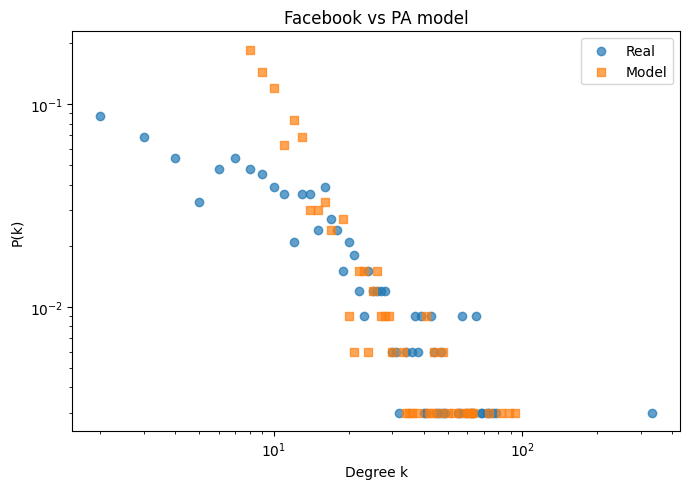

Section 2 passed! (visual check: both distributions visible on log-log)


In [7]:
# --- Validation ---
# This should produce a plot without errors
_g_ba = preferential_attachment(G_fb.number_of_nodes(), 8, seed=SEED)
compare_degree_dists(G_fb, _g_ba, title="Facebook vs PA model")
print("Section 2 passed! (visual check: both distributions visible on log-log)")

---
## Section 3: Hub Detection (10 pts)

Find all nodes whose degree exceeds `threshold_factor` times the average degree.
Return a list of those node IDs.

In [8]:
def find_hubs(G, threshold_factor=3.0):
    """Find hub nodes with degree > threshold_factor * avg_degree.

    Parameters
    ----------
    G : nx.Graph
    threshold_factor : float

    Returns
    -------
    list of nodes
    """
    # YOUR CODE HERE
    avg_deg = 2 * G.number_of_edges() / G.number_of_nodes()
    threshold = threshold_factor * avg_deg
    return [n for n, d in G.degree() if d > threshold]
    #raise NotImplementedError()

In [9]:
# --- Validation ---
_hubs = find_hubs(G_fb, threshold_factor=3.0)
assert isinstance(_hubs, list)
assert len(_hubs) > 0, "Facebook should have hubs"

_avg_deg = 2 * G_fb.number_of_edges() / G_fb.number_of_nodes()
_threshold = 3.0 * _avg_deg
for h in _hubs:
    assert G_fb.degree(h) > _threshold, (
        f"Node {h} degree {G_fb.degree(h)} below threshold {_threshold}"
    )

print(f"Found {len(_hubs)} hubs in Facebook (threshold = {_threshold:.1f})")
print(f"Hub degrees: {sorted([G_fb.degree(h) for h in _hubs], reverse=True)}")
print("Section 3 passed!")

Found 18 hubs in Facebook (threshold = 51.2)
Hub degrees: [333, 78, 76, 73, 72, 69, 68, 65, 65, 65, 63, 62, 59, 57, 57, 57, 56, 55]
Section 3 passed!


---
## Section 4: KS Degree Fit (10 pts)

Use the two-sample Kolmogorov-Smirnov test (`scipy.stats.ks_2samp`) to quantify how well
a model's degree distribution matches a real network.

Return the KS statistic (lower = better fit).

In [10]:
def ks_degree_fit(G_real, G_model):
    """Compute KS statistic between degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph

    Returns
    -------
    float  (KS statistic; lower = better fit)
    """
    # YOUR CODE HERE
    degs_real = [d for _, d in G_real.degree()]
    degs_model = [d for _, d in G_model.degree()]
    ks_stat, _ = stats.ks_2samp(degs_real, degs_model)
    return float(ks_stat)
    #raise NotImplementedError()

In [11]:
# --- Validation ---
n_fb = G_fb.number_of_nodes()
avg_deg_fb = 2 * G_fb.number_of_edges() / n_fb

_g_er = models.erdos_renyi(n_fb, avg_deg_fb)
_g_ba = preferential_attachment(n_fb, max(1, round(avg_deg_fb / 2)), seed=SEED)

_ks_er = ks_degree_fit(G_fb, _g_er)
_ks_ba = ks_degree_fit(G_fb, _g_ba)

assert isinstance(_ks_er, float)
assert 0 <= _ks_er <= 1
assert 0 <= _ks_ba <= 1

# BA should fit Facebook better than ER
assert _ks_ba < _ks_er, f"PA KS={_ks_ba:.3f} should be < ER KS={_ks_er:.3f}"
print(f"KS (ER vs Facebook): {_ks_er:.4f}")
print(f"KS (PA vs Facebook): {_ks_ba:.4f}")
print(f"PA fits better (lower KS)")
print("Section 4 passed!")

KS (ER vs Facebook): 0.4521
KS (PA vs Facebook): 0.3922
PA fits better (lower KS)
Section 4 passed!


---
## 5. CCDF & Power-Law Exponent (10 pts)

Implement two functions:

1. **`compute_ccdf(degrees)`** — given a degree sequence, return sorted arrays `(k_values, ccdf_values)` where `ccdf_values[i] = P(K ≥ k_values[i])`. Sort by k descending (largest degree first).

2. **`estimate_alpha(degrees, k_min)`** — estimate the power-law exponent using MLE:

$$\hat{\alpha} = 1 + n \left[ \sum_{i=1}^{n} \ln \frac{x_i}{x_{\min}} \right]^{-1}$$

where $x_i$ are degree values $\geq k_{\min}$ and $n$ is the count of such values.

Do NOT call `netsci.utils.fit_power_law`.

In [14]:
def compute_ccdf(degrees):
    """Compute the complementary CDF of a degree sequence.
    #sortez gradele, pt fiecare poz fac / n
    Parameters
    ----------
    degrees : array-like — degree values

    Returns
    -------
    (np.ndarray, np.ndarray) — (k_values, ccdf_values) sorted by k descending
    """
    # YOUR CODE HERE
    degs = np.array(sorted(degrees, reverse=True))
    n = len(degs)
    ccdf = np.arange(1, n + 1) / n
    return degs, ccdf
    #raise NotImplementedError()


def estimate_alpha(degrees, k_min=1):
    """Estimate power-law exponent using MLE.
    #cat de repede scade distributia gradelor, incet - multe hub uri
    Parameters
    ----------
    degrees : array-like — degree values
    k_min : int — minimum degree threshold

    Returns
    -------
    float — estimated exponent alpha
    """
    # YOUR CODE HERE
    degs = np.array([d for d in degrees if d >= k_min], dtype=float)
    n = len(degs)
    alpha = 1 + n / np.sum(np.log(degs / (k_min - 0.5)))
    return float(alpha)
    #raise NotImplementedError()

In [15]:
# --- Validation ---
# Test compute_ccdf
_degs = [1, 1, 2, 2, 3, 5, 10]
_k, _p = compute_ccdf(_degs)
assert len(_k) == len(_degs)
assert _p[0] < 0.5, "CCDF at max degree should be small (e.g. ~1/n)"
assert abs(_p[-1] - 1.0) < 1e-6, "CCDF of smallest degree should be ~1.0"
# k should be sorted descending
assert all(_k[i] >= _k[i + 1] for i in range(len(_k) - 1)), (
    "k values should be sorted descending"
)

# Test estimate_alpha on BA model
_g_ba = preferential_attachment(1000, 3, seed=SEED)
_ba_degs = [d for _, d in _g_ba.degree()]
_alpha = estimate_alpha(_ba_degs, k_min=3)
assert isinstance(_alpha, float)
# BA theory predicts γ=3.0 for large N, but finite-size effects lower it
assert 1.8 < _alpha < 4.0, f"Expected α in plausible range, got {_alpha:.2f}"
print(f"BA(1000, 3) exponent: α = {_alpha:.2f}")
print(f"(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)")
print("Section 5 passed!")

BA(1000, 3) exponent: α = 2.57
(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)
Section 5 passed!


---
## Section 6: Network Robustness (20 pts)

Implement two attack strategies on a network. Both functions should:
1. Make a **copy** of the graph
2. Remove the specified fraction of nodes
3. Return `(G_remaining, gcc_fraction)` where `gcc_fraction` is the size of the giant component divided by the **original** number of nodes

`random_removal(G, fraction)`: remove nodes uniformly at random. Create the RNG inside the function with `np.random.default_rng(SEED)`.

`targeted_removal(G, fraction)`: remove nodes in order of **decreasing degree**, recalculating degrees after each removal.

In [16]:
def random_removal(G, fraction):
    """Remove a random fraction of nodes and measure giant component.

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    # YOUR CODE HERE
    N = G.number_of_nodes()
    n_remove = int(N * fraction)
    G_copy = G.copy()
    rng = np.random.default_rng(SEED)
    nodes_to_remove = rng.choice(list(G_copy.nodes()), size=n_remove, replace=False)
    G_copy.remove_nodes_from(nodes_to_remove)
    if G_copy.number_of_nodes() > 0:
        gcc = len(max(nx.connected_components(G_copy), key=len)) / N
    else:
        gcc = 0.0
    return G_copy, gcc
    #raise NotImplementedError()


def targeted_removal(G, fraction):
    """Remove highest-degree nodes one at a time (recalculating degrees).

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    # YOUR CODE HERE
    N = G.number_of_nodes()
    n_remove = int(N * fraction)
    G_copy = G.copy()
    for _ in range(n_remove):
        if G_copy.number_of_nodes() == 0:
            break
        top_node = max(G_copy.nodes(), key=lambda v: G_copy.degree(v))
        G_copy.remove_node(top_node)
    if G_copy.number_of_nodes() > 0:
        gcc = len(max(nx.connected_components(G_copy), key=len)) / N
    else:
        gcc = 0.0
    return G_copy, gcc
    #raise NotImplementedError()

In [17]:
# --- Validation ---
_G_r, _gcc_r = random_removal(G_air, 0.2)
assert isinstance(_G_r, nx.Graph)
assert _G_r.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_r <= 1.0
# Original unchanged
assert G_air.number_of_nodes() == 500, "Original graph should not be modified"

_G_t, _gcc_t = targeted_removal(G_air, 0.2)
assert isinstance(_G_t, nx.Graph)
assert _G_t.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_t <= 1.0

# Targeted should reduce giant component more than random
assert _gcc_t < _gcc_r, (
    f"Targeted ({_gcc_t:.3f}) should shrink GCC more than random ({_gcc_r:.3f})"
)
print(f"Random removal (20%): GCC = {_gcc_r:.3f}")
print(f"Targeted removal (20%): GCC = {_gcc_t:.3f}")
print("Targeted attack is more devastating — the robustness paradox!")
print("Section 6 passed!")

Random removal (20%): GCC = 0.774
Targeted removal (20%): GCC = 0.010
Targeted attack is more devastating — the robustness paradox!
Section 6 passed!


---
## Written Questions (15 pts)

### Question 1 (5 pts)

Why does the BA degree distribution look different from ER on a log-log plot?
What mechanism in the BA model causes the fat tail, and why can't ER produce one?

**Hints to guide your thinking:**
- *On a log-log plot, what shape does a Poisson distribution make? What about a power law?*
- *In ER, each edge exists independently with the same probability. What does this imply about the variance of degree?*
- *In BA, a node that arrives early accumulates connections over time. Why can't this "rich get richer" dynamic happen in ER, where all edges are assigned simultaneously?*

**Your Answer:**
In modelul ER, muchiile sunt generate independent si toate nodurile sunt echivalente, asta duce la o distribuție de tip Poisson, care n-are hub-uri si nici coada groasa.
Dar modelul BA introduce un soi de crestere: nodurile cu grad mare atrag mai multe conexiuni. 
Si atunci avem un mecanism de genul "rich get richer" care imi face o distribuție de tip power-law, care apare ca o linie dreaptă pe log-log si are o coadă groasă. 
ER nu poate sa produca acest comportament deoarece nu include atasare preferentiala si nici evolutie în timp


### Question 2 (5 pts)

In the lab, we saw that BA networks are "ultra-small" — their average path length grows as
$\ln N / \ln \ln N$, slower than ER's $\ln N$.

(a) Explain *why* hubs create this shortcut effect. (Think about what happens when you try to
route between two random nodes — how many hops to reach a hub, and how many hops between hubs?)

(b) We also saw that Facebook's degree distribution is better fit by an exponential than a power
law, despite having clear hubs. Does a network need to be "truly scale-free" (strict power-law
degree distribution) to benefit from the ultra-small property, or is having *some* high-degree
hubs sufficient? Justify your reasoning.

**Hints to guide your thinking:**
- *In a scale-free network, most nodes are within 1-2 hops of a hub. Why?*
- *The ultra-small property depends on the existence of high-degree nodes, not on the exact shape of the degree distribution. Think about what ⟨k²⟩ measures.*
- *Broido & Clauset (2019) found that few networks are "strictly" scale-free. Does this mean the BA model is useless?*

**Your Answer:**
(a) Hub-urile reduc distantele pt ca majoritatea nodurilor sunt la 1–2 pasi de un hub si ca sa conectam doua noduri random, de obicei urcam la un hub, traversezam intre hub-uri (acelea care is bine conectate), apoi coboram la destinatie. 
Iar asta creeaza scurtaturi in retea si duce la distante medii foarte mici.

(b) O retea nu trb să fie neaparat scale free ca sa aiba proprietatea ultra small si avem nevoie doar de noduri cu un grad mare (gen hub-uri), deoarece acestea creeaza scurtaturi intre parti ale retelei. 
Si chiar daca distributia de grade este mai mult exponentiala, faptul ca exista hub uri ne reduce cu mult distantele medii, asa ca proprietatea ultra small depinde mai mult de existenta nodurilor cu grad mare decat de cum arata exact distributia.


### Question 3 (5 pts)

Why does targeted hub removal push the Molloy-Reed ratio (⟨k²⟩/⟨k⟩) below 2 faster than
random removal?

**Use your results from Section 6** to support your answer. Quote the GCC fractions for
random vs targeted removal at 20% and explain the asymmetry in terms of ⟨k²⟩.

**Hints to guide your thinking:**
- *The Molloy-Reed ratio depends heavily on ⟨k²⟩ — the average squared degree. Which nodes contribute most to this quantity?*
- *In a scale-free network, hubs have degree much larger than average. How does removing a node with degree 100 vs degree 5 affect ⟨k²⟩?*
- *Random removal mostly hits low-degree nodes (because there are many more of them). How much does removing a degree-5 node change ⟨k²⟩?*

**Your Answer:**
Raportul Molloy–Reed depinde mult de ⟨k²⟩ si cantitatea lui depinde mult de nodurile cu grad mare (gen hub urile) pt ca la ele gradul este ridicat la patrat. 
Si in eliminarea targeted, eliminam exact aceste hub uri si ne scad mult ⟨k²⟩ urile si raportul de ⟨k²⟩/⟨k⟩ sub valoarea de 2. 
Dar eliminarea care nu e targeted afectează afecteaza doar nodurile cu grad mic, cele care contribuie foarte puțin la ⟨k²⟩ si atunci raportul scade mult mai lent. 
De asta reteaua se fragmenteaza mult mai rapid in cazul eliminarii targeted.
